# CS - Graphical Models in Finance

### Importing libraries

In [1]:
%pip install --quiet --upgrade matplotlib
%pip install --quiet --upgrade pandas
%pip install --quiet --upgrade numpy
%pip install --quiet --upgrade tqdm
%pip install --quiet --upgrade ipywidgets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import math
from datetime import date
from tqdm import tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.46.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.2 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.46.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.2 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip

As the data is stored in CSV files inside the `/data/yahoo-finance-dataset` directory, we will need to list all the files in that directory and load them into a pandas DataFrame.

In [2]:
data_directory = '../data/yahoo-finance-dataset'

In [3]:
def list_assets(directory):
    file_list = os.listdir(directory)
    assets_list = [file_name.replace(".csv", "") for file_name in file_list if file_name.endswith('.csv')]
    return sorted(assets_list)

In [4]:
assets = list_assets(data_directory)
assets

['000001.SS',
 '0001.HK',
 '0002.HK',
 '0006.HK',
 '0012.HK',
 '0016.HK',
 '0669.HK',
 '0823.HK',
 '0A0H.IL',
 '0ACP.L',
 '0DHC.IL',
 '0IIF.IL',
 '0KFE.IL',
 '0MGI.IL',
 '0MHU.IL',
 '0NTU.IL',
 '0P00007ZH9',
 '0P0000P14B',
 '0P00016T36',
 '0P00017HNT.F',
 '0P0001KRJP.TW',
 '0P0001O1TG.F',
 '0P0001QWSZ',
 '0V6.SG',
 '0VD0.DU',
 '1038.HK',
 '1113.HK',
 '1878.T',
 '1904.T',
 '1925.T',
 '1928.HK',
 '1977.HK',
 '1ADEN.MI',
 '1BOL.MI',
 '1JP.F',
 '1LEG.MI',
 '1LNB.HA',
 '1N8U.DU',
 '1USB.MI',
 '2388.HK',
 '2693.HK',
 '3309.T',
 '34D.HA',
 '3M00.F',
 '4183.T',
 '4188.T',
 '4204.T',
 '4307.T',
 '4543.T',
 '4612.T',
 '4620.T',
 '4704.T',
 '4720.F',
 '4755.T',
 '4WF.F',
 '5020.T',
 '5B4.HA',
 '5JP0.F',
 '5NU.F',
 '5ZM.HM',
 '6098.T',
 '61F.F',
 '6288.HK',
 '6367.T',
 '6503.T',
 '6504.T',
 '6723.T',
 '6724.T',
 '6752.T',
 '6823.HK',
 '6902.T',
 '6971.T',
 '69B.MU',
 '6EQ.F',
 '6L=F',
 '6PU.DU',
 '6XQ.F',
 '7181.T',
 '7201.T',
 '7202.T',
 '7259.T',
 '7272.T',
 '7701.T',
 '7752.T',
 '7911.T',
 '793

In [5]:
len(assets)

1146

We successfully loaded the list of assets (1160).

### Data Exploration

Example of data for one asset

First we define a function to load the data for one asset.

In [6]:
def load_df_from_csv(directory, asset):
    file_path = os.path.join(directory, asset + '.csv')
    df = pd.read_csv(file_path)
    return df

We also define a function that summarizes the key informations and statistics of the data. (e.g. number of rows, number of columns, number of missing values, etc.)

In [7]:
def show_df_info(dataframe):
    print(dataframe.info())
    print(dataframe.describe())
    print(dataframe.head())
    print(dataframe.tail())

And finally, we define a function that plots the data for one asset. The plot shows the open, close and volume over time.

In [8]:
def plot_df_asset(dataframe):
    dataframe.plot(x='Date', y='Open', title='Open price')
    dataframe.plot(x='Date', y='Close', title='Close price')
    dataframe.plot(x='Date', y='Volume', title='Volume')

We will show those informations for one asset

In [9]:
asset = assets[100]

In [10]:
df = load_df_from_csv(data_directory, asset)
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-03-26 00:00:00+01:00,1.4585,1.5605,1.4585,1.5605,0,0.0,0.0
1,2021-03-29 00:00:00+02:00,2.0595,2.1840,1.8565,1.9080,20,0.0,0.0
2,2021-03-30 00:00:00+02:00,2.0325,2.0325,2.0325,2.0325,0,0.0,0.0
3,2021-03-31 00:00:00+02:00,1.9350,1.9875,1.8575,1.9875,0,0.0,0.0
4,2021-04-01 00:00:00+02:00,1.8375,1.9325,1.8375,1.9325,0,0.0,0.0
...,...,...,...,...,...,...,...,...
1292,2026-04-23 00:00:00+02:00,0.6750,0.6750,0.6750,0.6750,0,0.0,0.0
1293,2026-04-24 00:00:00+02:00,0.5950,0.6150,0.5950,0.6150,3435,0.0,0.0
1294,2026-04-27 00:00:00+02:00,0.6000,0.6100,0.6000,0.6000,0,0.0,0.0
1295,2026-04-28 00:00:00+02:00,0.6000,0.6100,0.6000,0.6100,0,0.0,0.0


In [11]:
show_df_info(df)

<class 'pandas.DataFrame'>
RangeIndex: 1297 entries, 0 to 1296
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          1297 non-null   str    
 1   Open          1297 non-null   float64
 2   High          1297 non-null   float64
 3   Low           1297 non-null   float64
 4   Close         1297 non-null   float64
 5   Volume        1297 non-null   int64  
 6   Dividends     1297 non-null   float64
 7   Stock Splits  1297 non-null   float64
dtypes: float64(6), int64(1), str(1)
memory usage: 112.9 KB
None
              Open         High          Low        Close        Volume  \
count  1297.000000  1297.000000  1297.000000  1297.000000   1297.000000   
mean      0.494082     0.501903     0.487944     0.495019    163.862760   
std       0.503916     0.511306     0.497912     0.504091   1268.643057   
min       0.080000     0.080000     0.077500     0.077500      0.000000   
25%       0.148000     0.149000    

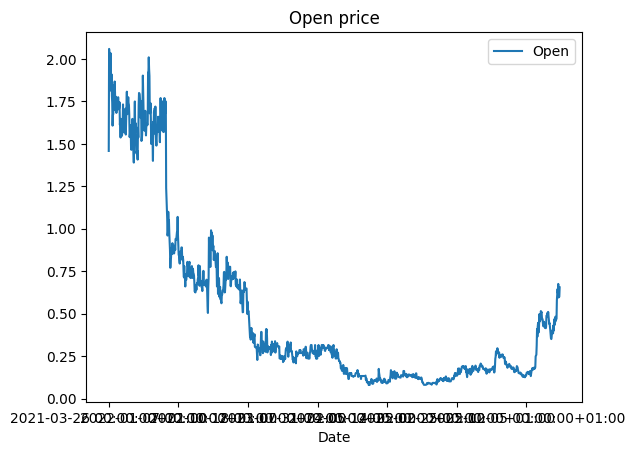

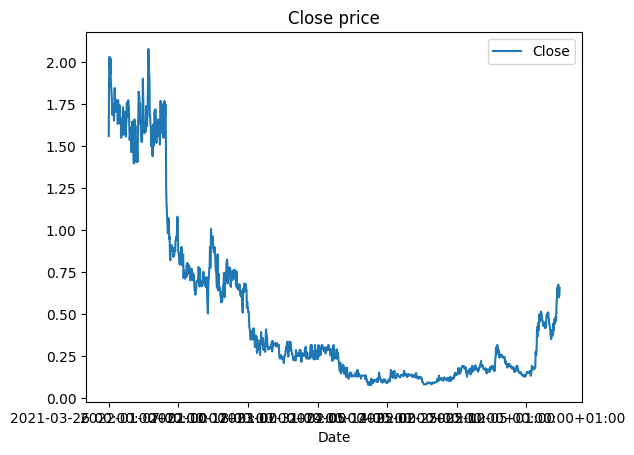

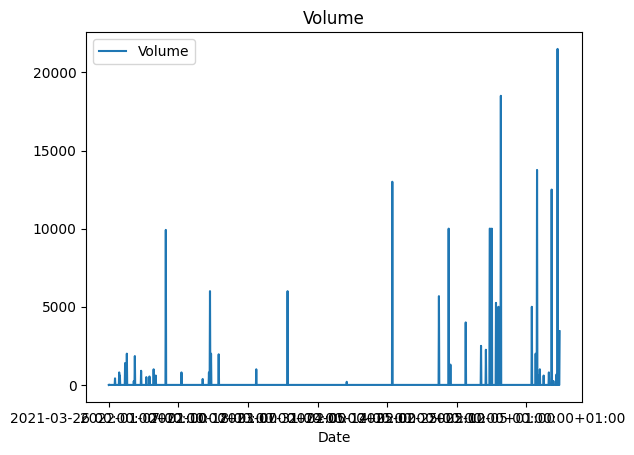

In [12]:
plot_df_asset(df)

At the first sight, the data looks good. It seems to have no missing values and the data is well formatted. We can check the data for `APPLE` which are well known assets.

In [13]:
asset = 'AAPL'

In [14]:
df = load_df_from_csv(data_directory, asset)
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1980-12-12 00:00:00-05:00,0.098297,0.098725,0.098297,0.098297,469033600,0.0,0.0
1,1980-12-15 00:00:00-05:00,0.093597,0.093597,0.093169,0.093169,175884800,0.0,0.0
2,1980-12-16 00:00:00-05:00,0.086758,0.086758,0.086331,0.086331,105728000,0.0,0.0
3,1980-12-17 00:00:00-05:00,0.088468,0.088895,0.088468,0.088468,86441600,0.0,0.0
4,1980-12-18 00:00:00-05:00,0.091033,0.091460,0.091033,0.091033,73449600,0.0,0.0
...,...,...,...,...,...,...,...,...
11431,2026-04-23 00:00:00-04:00,275.049988,275.769989,271.649994,273.429993,33399600,0.0,0.0
11432,2026-04-24 00:00:00-04:00,272.760010,273.059998,269.649994,271.059998,38157100,0.0,0.0
11433,2026-04-27 00:00:00-04:00,266.089996,268.359985,265.070007,267.609985,41466800,0.0,0.0
11434,2026-04-28 00:00:00-04:00,272.339996,273.230011,268.660004,270.709991,39978600,0.0,0.0


In [15]:
show_df_info(df)

<class 'pandas.DataFrame'>
RangeIndex: 11436 entries, 0 to 11435
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          11436 non-null  str    
 1   Open          11436 non-null  float64
 2   High          11436 non-null  float64
 3   Low           11436 non-null  float64
 4   Close         11436 non-null  float64
 5   Volume        11436 non-null  int64  
 6   Dividends     11436 non-null  float64
 7   Stock Splits  11436 non-null  float64
dtypes: float64(6), int64(1), str(1)
memory usage: 994.1 KB
None
               Open          High           Low         Close        Volume  \
count  11436.000000  11436.000000  11436.000000  11436.000000  1.143600e+04   
mean      29.569249     29.888406     29.267680     29.591067  3.078627e+08   
std       60.748581     61.396418     60.146384     60.799027  3.329610e+08   
min        0.038037      0.038037      0.037609      0.037609  0.000000e+00   
25%        0.

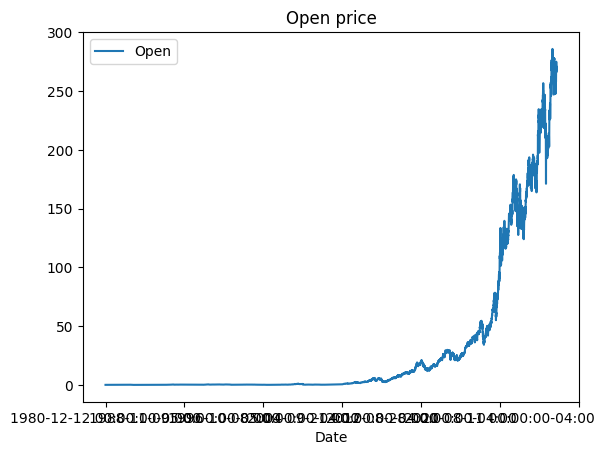

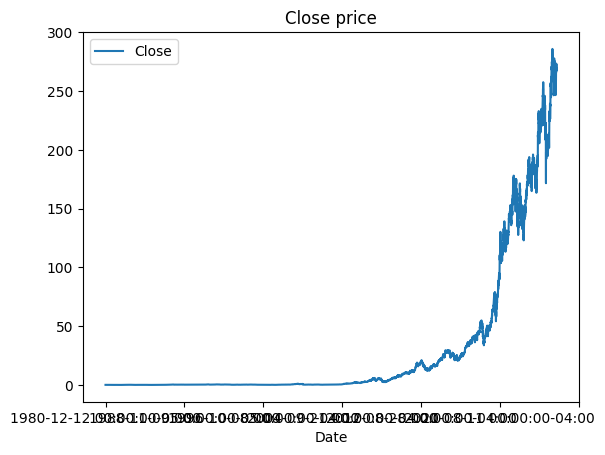

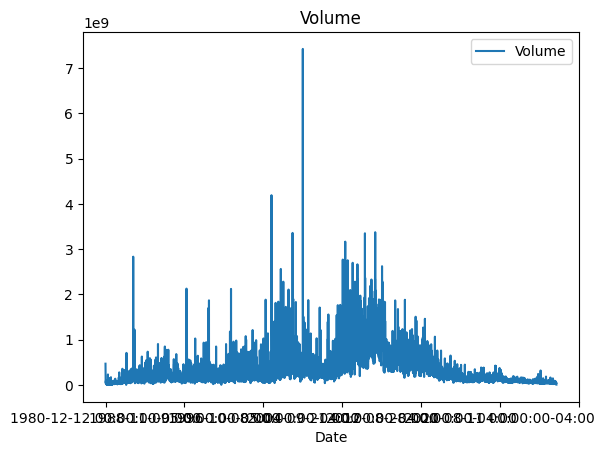

In [16]:
plot_df_asset(df)

Before continuing, we check that for all assets, the first and last date are the same.

In [17]:
def is_opening_closing_dates_same(directory, curr_assets):
    opening_date = set()
    closing_date = set()
    for curr_asset in curr_assets:
        dataframe = load_df_from_csv(directory, curr_asset)
        opening_date.add(dataframe['Date'].min())
        closing_date.add(dataframe['Date'].max())
    return len(opening_date) == 1 and len(closing_date) == 1

In [18]:
is_opening_closing_dates_same(data_directory, assets)

False

Since the opening and closing dates are not the same for all assets, we will need to plot the starting and ending dates for all assets, and choose where we will truncate the data.

In [19]:
def get_opening_closing_dates(directory, curr_assets):
    """
    Function that returns the opening and closing dates of the assets (as a dictionary).
    :param directory: Directory where the assets are stored.
    :param curr_assets: List of assets to check.
    :return: A tuple of two dictionaries, one for opening dates and one for closing dates.
    The keys are the asset names and the values are the dates.
    """
    opening_dates = dict()
    closing_dates = dict()
    for curr_asset in curr_assets:
        dataframe = load_df_from_csv(directory, curr_asset)
        min = dataframe['Date'].min()
        max = dataframe['Date'].max()
        if not pd.isna(min) and not pd.isna(max):
            opening_dates[curr_asset] = min
            closing_dates[curr_asset] = max
    return opening_dates, closing_dates

In [ ]:
opening_dates, closing_dates = get_opening_closing_dates(data_directory, assets)


{'000001.SS': '1997-07-02 00:00:00+08:00', '0001.HK': '2000-01-04 00:00:00+08:00', '0002.HK': '2000-01-04 00:00:00+08:00', '0006.HK': '2000-01-04 00:00:00+08:00', '0012.HK': '2000-01-04 00:00:00+08:00', '0016.HK': '2000-01-04 00:00:00+08:00', '0669.HK': '2004-06-14 00:00:00+08:00', '0823.HK': '2007-10-31 00:00:00+08:00', '0A0H.IL': '2014-01-21 00:00:00+00:00', '0ACP.L': '2023-10-11 00:00:00+01:00', '0DHC.IL': '2007-11-02 00:00:00+00:00', '0IIF.IL': '2011-04-11 00:00:00+01:00', '0KFE.IL': '2001-04-30 00:00:00+01:00', '0MGI.IL': '2011-04-11 00:00:00+01:00', '0MHU.IL': '2008-05-08 00:00:00+01:00', '0NTU.IL': '2008-06-05 00:00:00+01:00', '0P00007ZH9': '2022-03-07 00:00:00-05:00', '0P0000P14B': '2022-03-04 00:00:00-05:00', '0P00016T36': '2019-01-02 00:00:00-05:00', '0P00017HNT.F': '2018-01-02 00:00:00+01:00', '0P0001KRJP.TW': '2020-10-06 00:00:00+08:00', '0P0001O1TG.F': '2021-12-20 00:00:00+01:00', '0P0001QWSZ': '2023-05-25 00:00:00-04:00', '0V6.SG': '2017-09-25 00:00:00+02:00', '0VD0.DU': 

We will plot an histogram to check the distribution of the opening and closing dates

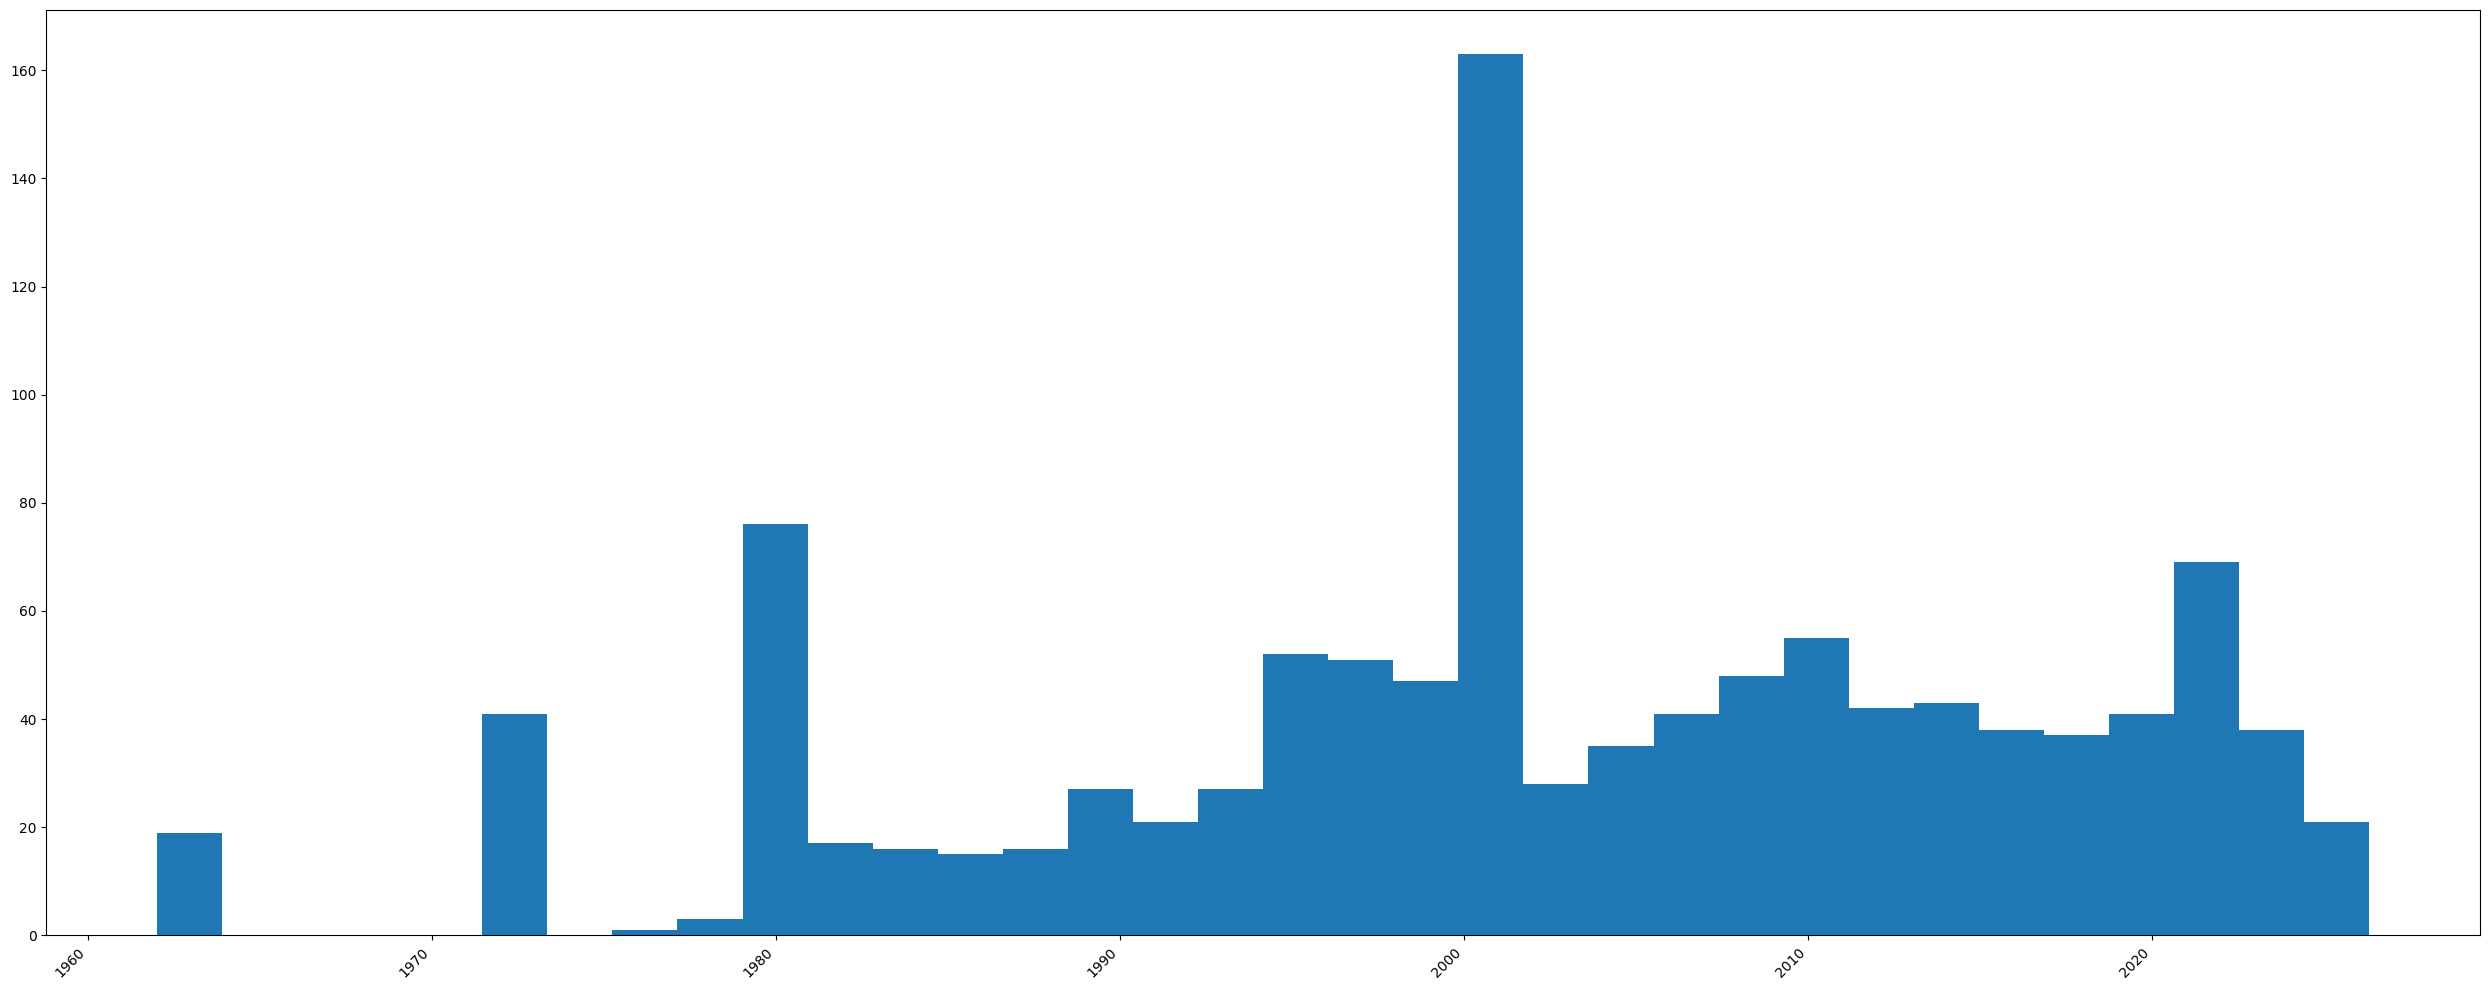

In [23]:
plt.figure(figsize=(25, 10))
plt.hist(pd.to_datetime(list(opening_dates.values()), utc=True), bins=round(math.sqrt(len(opening_dates.values()))))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

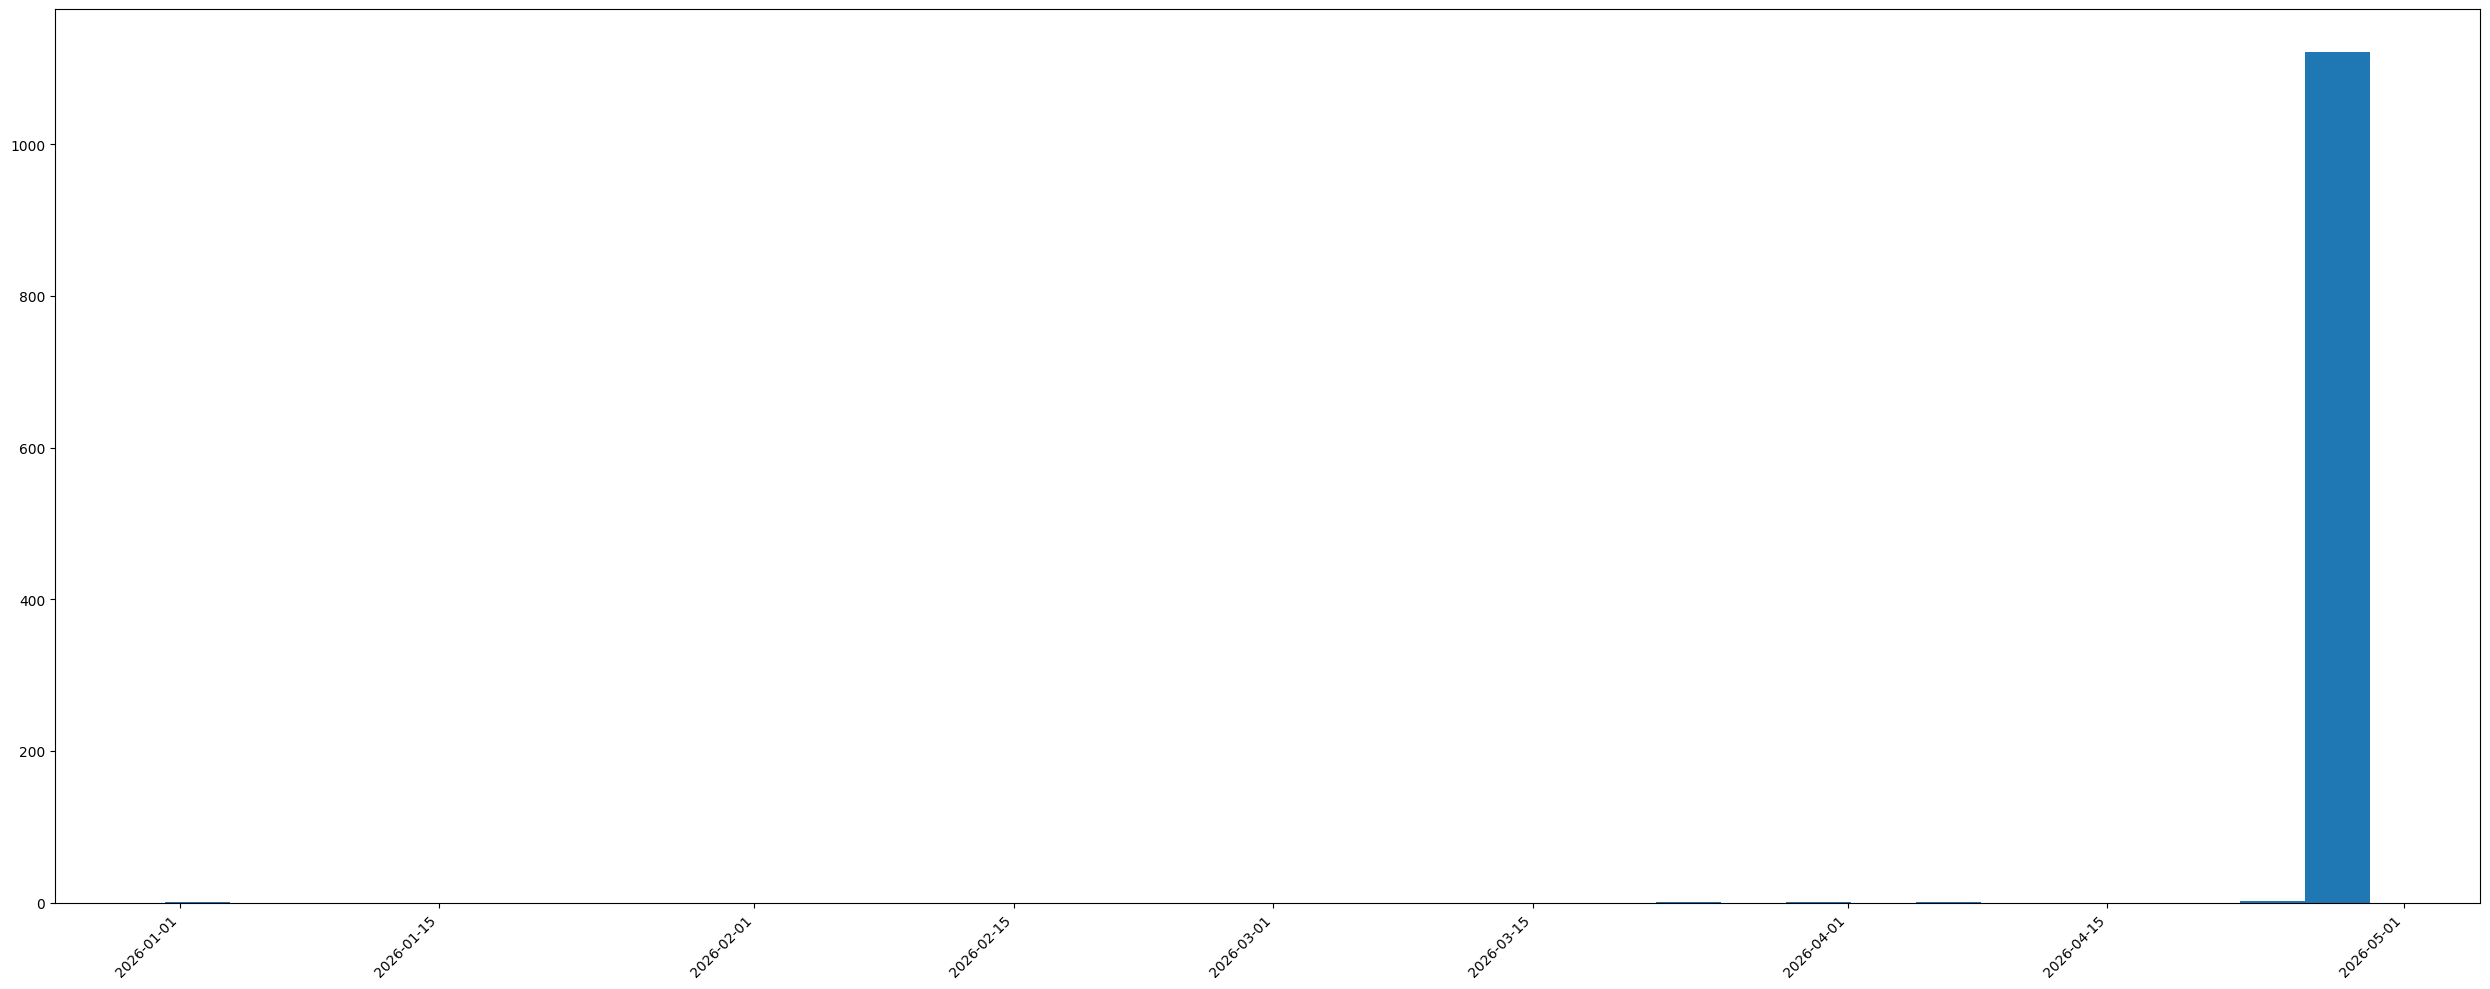

In [24]:
plt.figure(figsize=(25, 10))
plt.hist(pd.to_datetime(list(closing_dates.values()), utc=True), bins=round(math.sqrt(len(opening_dates.values()))))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

We will take 2003-01-01 as the opening date and 2025-03-12 as the closing date as it seems that most of the assets are available for that period (and we don't loose too much historical data).

In [25]:
opening_date = "2003-01-02"
closing_date = "2025-03-12"

It seems there is also a problem as assets have different number of observations. This could be caused as some assets are not traded every day and as they may be in different markets. We will add for each assets that doesn't have a value for a given date the value of the previous day. Then we will check again the number of observations for each asset.

In [26]:
def add_missing_dates_in_df(dataframe, opening_date, closing_date, columns_names):
    # We convert the 'Date' column to datetime format
    dataframe['Date'] = pd.to_datetime(dataframe['Date'], format='%Y-%m-%d')
    new_df_dict = []

    # We loop through the date range and check if the date is in the dataframe
    for date in pd.date_range(start=opening_date, end=closing_date):
        if len(dataframe[dataframe['Date'] == date]) == 0:
            # If the date is not in the dataframe, we need to fill it with the previous date values
            prev_date_offset = 1
            max_offset = 15
            prev_date = date - pd.Timedelta(days=prev_date_offset)

            # We check if the previous date is in the dataframe (or if it is out of range)
            if not prev_date > pd.to_datetime(opening_date) and pd.to_datetime(closing_date) <= date:
                raise ValueError(f"Date {prev_date} is out of range.")
            prev_date_row = dataframe[dataframe['Date'] == prev_date]

            # We loop through the previous dates until we find a date that is in the dataframe
            while len(prev_date_row) == 0:
                prev_date_offset += 1
                # We check if we have reached the maximum offset of shifted dates
                if prev_date_offset >= max_offset:
                    return None
                prev_date = date - pd.Timedelta(days=prev_date_offset)

                # We check if the previous date is in the dataframe (or if it is out of range)
                if not prev_date > pd.to_datetime(opening_date) and pd.to_datetime(closing_date) <= date:
                    raise ValueError(f"Date {prev_date} is out of range.")
                prev_date_row = dataframe[dataframe['Date'] == prev_date]

            # Now prev_date_row contains the row with the previous date
            prev_date_row = prev_date_row.reset_index()

            # We are now filling all the shifted values with the previous date values
            # We copy the previous date row columns of interest
            new_row = {col: prev_date_row.loc[0, col] for col in columns_names}
            for i in range(len(prev_date_row)):
                curr_date = date - pd.Timedelta(days=i)
                new_row['Date'] = curr_date
                # We append our new dataframe
                new_df_dict.append(new_row)

        else:
            # If the date is in the dataframe, we need to copy the row in the new dataframe
            new_row = dataframe[dataframe['Date'] == date].iloc[0]
            new_row = new_row.to_dict()
            new_df_dict.append(new_row)

    # We create a new dataframe from the dictionary
    new_df = pd.DataFrame(new_df_dict)
    # We sort values by date and reset the index
    new_df = new_df.sort_values(by='Date').reset_index(drop=True)
    # We convert the 'Date' column to datetime format
    new_df['Date'] = pd.to_datetime(new_df['Date'], format='%Y-%m-%d')

    return new_df

We also define a function to standardize the data on the same period and store mean and standard deviation for each asset in order to inverse the standardization later.

In [27]:
def standardize_assets_dataframe(dataframe, columns_to_standardize):
    all_mean = dataframe.mean(axis=0, numeric_only=True)
    all_std = dataframe.std(axis=0, numeric_only=True)
    # Checking that columns we need are present in all_mean and all_std
    for column in columns_to_standardize:
        if not column in all_mean or not column in all_std:
            return None

    for column in columns_to_standardize:
        mean = all_mean[column]
        std = all_std[column]
        dataframe[column + "_mean"] = mean
        dataframe[column + "_std"] = std
        dataframe[column] = (dataframe[column] - mean) / std

    return dataframe

Now we will create a new dataframe with the opening and closing dates for all assets, we will add a column for the ticker

In [28]:
def concat_and_standardize_assets_dataframe(directory, curr_assets, opening_date, closing_date):
    # Handling the first asset
    first_idx = 0
    concat_df = load_df_from_csv(directory, curr_assets[first_idx])
    # We only keep the date part of the datetime
    concat_df['Date'] = concat_df['Date'].apply(lambda x: x.split(' ')[0])

    # If the loaded dataframe dosn't match our opening and closing dates requirements, we need to load the next asset

    while pd.isna(concat_df['Date'].min()) or pd.isna(concat_df['Date'].max()) or concat_df[concat_df['Date'] == opening_date].empty:
        first_idx += 1
        concat_df = load_df_from_csv(directory, curr_assets[first_idx])
        concat_df = concat_df[(concat_df['Date'] >= opening_date) & (concat_df['Date'] <= closing_date)]

    # We add the ticker column to the dataframe
    concat_df['Ticker'] = curr_assets[first_idx]

    # We use the function previously defined to add missing dates in the dataframe and standardize the columns
    concat_df = add_missing_dates_in_df(concat_df, opening_date, closing_date, ['Open', 'High', 'Low', 'Close', 'Volume', 'Ticker'])
    concat_df = standardize_assets_dataframe(concat_df, ['Open', 'High', 'Low', 'Close', 'Volume'])

    # We loop through the rest of the assets and concatenate them to the dataframe
    for curr_asset in tqdm(curr_assets[first_idx+1:]):
        dataframe = load_df_from_csv(directory, curr_asset)
        dataframe['Date'] = dataframe['Date'].apply(lambda x: x.split(' ')[0])

        # If the assets don't match our requirements, we need to skip them
        if pd.isna(dataframe['Date'].min()) or pd.isna(dataframe['Date'].max()):
            continue

        if dataframe[dataframe['Date'] == opening_date].empty:
            # print(f"Skipping {curr_asset} no values for opening date...")
            continue

        # We only keep the date part of the datetime
        dataframe = dataframe[(dataframe['Date'] >= opening_date) & (dataframe['Date'] <= closing_date)]

        dataframe['Ticker'] = curr_asset
        dataframe = add_missing_dates_in_df(dataframe, opening_date, closing_date, ['Open', 'High', 'Low', 'Close', 'Volume', 'Ticker'])

        # We standardize the dataframe and concatenate it to the main dataframe
        if dataframe is not None:
            dataframe_std = standardize_assets_dataframe(dataframe, ['Open', 'High', 'Low', 'Close', 'Volume'])
        else:
            # print(f"Skipping {curr_asset} filling missing dates failed...")
            continue

        if dataframe is not None:
            concat_df = pd.concat([concat_df, dataframe_std])
        else:
            # print( f"Skipping {curr_asset} standardizing failed...")
            continue

    return concat_df

We apply the function to all assets and we will store the data in a new dataframe.

In [29]:
concatenated_df = concat_and_standardize_assets_dataframe(data_directory, assets, opening_date, closing_date)

100%|██████████| 1145/1145 [44:48<00:00,  2.35s/it] 


In [114]:
concatenated_df[concatenated_df['Date'] == opening_date]

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,Open_mean,Open_std,High_mean,High_std,Low_mean,Low_std,Close_mean,Close_std,Volume_mean,Volume_std,Capital Gains
0,2003-01-02,-1.622976,-1.629134,-1.652047,-1.657231,-0.731993,0.0,0.0,000001.SS,2720.952665,846.297141,2744.256785,855.001950,2698.080982,835.698185,2724.086145,846.868132,1.764160e+05,2.410078e+05,NaN
0,2003-01-02,-1.850897,-1.857447,-1.844569,-1.856712,-1.213763,0.0,0.0,0001.HK,43.500155,15.979528,43.904025,16.066757,43.066426,15.873576,43.486960,15.959315,6.825908e+06,4.225270e+06,NaN
0,2003-01-02,-1.738033,-1.738382,-1.734112,-1.737014,-1.166255,0.0,0.0,0002.HK,41.602704,16.977079,41.864692,17.080063,41.301743,16.864127,41.593455,16.981717,3.209230e+06,2.013155e+06,NaN
0,2003-01-02,-1.573810,-1.574729,-1.569267,-1.570279,-0.845474,0.0,0.0,0011.HK,80.262320,32.917319,80.880009,33.181514,79.536954,32.605017,80.233542,32.918423,1.939968e+06,1.451897e+06,NaN
0,2003-01-02,-2.435446,-2.447274,-2.435132,-2.437474,-0.917987,0.0,0.0,0019.HK,43.668868,13.309214,44.123642,13.415283,43.180365,13.180119,43.656727,13.285411,2.068948e+06,1.490160e+06,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,2003-01-02,-1.559371,-1.554476,-1.552965,-1.550092,-0.577693,0.0,0.0,XOM,52.906418,23.051966,53.389110,23.263616,52.417949,22.841870,52.914536,23.048264,1.893203e+07,1.061677e+07,NaN
0,2003-01-02,-1.171240,-1.168766,-1.170828,-1.167501,-0.140874,0.0,0.0,YUM,53.818562,40.815954,54.283980,41.121623,53.354176,40.505135,53.832118,40.814962,3.767305e+06,2.760226e+06,NaN
0,2003-01-02,-1.547747,-1.557754,-1.582185,-1.587945,0.160274,0.0,0.0,ZBH,85.466379,31.771407,86.319182,32.030967,84.598984,31.466763,85.481966,31.744263,1.602386e+06,1.001153e+06,NaN
0,2003-01-02,-0.764006,-0.763144,-0.763416,-0.761086,0.836269,0.0,0.0,ZBRA,129.940497,136.529530,131.588353,138.179120,128.148559,134.584790,129.938581,136.449423,4.354248e+05,4.366121e+05,NaN


Saving the dataframe to a csv file, uncomment the line below to load the data from the csv file and skip previous steps.

In [ ]:
# Save concatenated_df to CSV
concatenated_df.to_csv(os.path.join(data_directory, '../concatenated_data.csv'), index=False)
#concatenated_df = pd.read_csv(os.path.join(data_directory, '../concatenated_data.csv'))

We check the symmetric difference between two random assets dates to see if they are the same.

In [119]:
df1 = concatenated_df[concatenated_df["Ticker"] == "0002.HK"]
df2 = concatenated_df[concatenated_df["Ticker"] == "0011.HK"]

# Symmetric difference between the two dataframes date columns
print(set(df1['Date']) ^ set(df2['Date']))

set()


Checking the number of assets kept after the cleaning process.

In [120]:
print(len(concatenated_df['Ticker'].unique()), len(assets))

643 1160


Checking that the opening and closing dates are the same for all assets, and that the dataframe is correctly standardized

In [121]:
assert len(concatenated_df[concatenated_df["Date"] == concatenated_df.Date.min()]) == len(concatenated_df["Ticker"].unique()), 'Opening date is not the same for all assets'
assert len(concatenated_df[concatenated_df["Date"] == concatenated_df.Date.max()]) == len(concatenated_df["Ticker"].unique()), 'Closing date is not the same for all assets'

In [122]:
concatenated_df[concatenated_df["Ticker"] == assets[0]].describe()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Open_mean,Open_std,High_mean,High_std,Low_mean,Low_std,Close_mean,Close_std,Volume_mean,Volume_std,Capital Gains
count,8106,8.106000e+03,8.106000e+03,8.106000e+03,8.106000e+03,8106.000000,5381.0,5381.0,8.106000e+03,8.106000e+03,8.106000e+03,8.106000e+03,8.106000e+03,8.106000e+03,8.106000e+03,8.106000e+03,8.106000e+03,8.106000e+03,0.0
mean,2014-02-05 11:59:59.999999744,-2.244004e-16,-2.524504e-16,-2.244004e-16,2.524504e-16,0.000000,0.0,0.0,2.720953e+03,8.462971e+02,2.744257e+03,8.550020e+02,2.698081e+03,8.356982e+02,2.724086e+03,8.468681e+02,1.764160e+05,2.410078e+05,NaN
min,2003-01-02 00:00:00,-2.024173e+00,-2.016761e+00,-2.034051e+00,-2.022259e+00,-0.731993,0.0,0.0,2.720953e+03,8.462971e+02,2.744257e+03,8.550020e+02,2.698081e+03,8.356982e+02,2.724086e+03,8.468681e+02,1.764160e+05,2.410078e+05,NaN
25%,2008-07-20 06:00:00,-6.940832e-01,-6.845134e-01,-6.915200e-01,-6.906810e-01,-0.458143,0.0,0.0,2.720953e+03,8.462971e+02,2.744257e+03,8.550020e+02,2.698081e+03,8.356982e+02,2.724086e+03,8.468681e+02,1.764160e+05,2.410078e+05,NaN
50%,2014-02-05 12:00:00,1.996719e-01,2.024184e-01,2.072602e-01,2.004897e-01,-0.187612,0.0,0.0,2.720953e+03,8.462971e+02,2.744257e+03,8.550020e+02,2.698081e+03,8.356982e+02,2.724086e+03,8.468681e+02,1.764160e+05,2.410078e+05,NaN
75%,2019-08-24 18:00:00,6.078393e-01,6.011216e-01,6.146466e-01,6.082969e-01,0.336852,0.0,0.0,2.720953e+03,8.462971e+02,2.744257e+03,8.550020e+02,2.698081e+03,8.356982e+02,2.724086e+03,8.468681e+02,1.764160e+05,2.410078e+05,NaN
max,2025-03-12 00:00:00,3.942440e+00,3.952958e+00,3.999808e+00,3.976972e+00,41.030971,0.0,0.0,2.720953e+03,8.462971e+02,2.744257e+03,8.550020e+02,2.698081e+03,8.356982e+02,2.724086e+03,8.468681e+02,1.764160e+05,2.410078e+05,NaN
std,NaN,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.0,0.0,2.196565e-10,5.718801e-11,4.370392e-10,7.049019e-11,1.268823e-10,4.752403e-11,3.429007e-10,7.003541e-11,5.617386e-09,2.357556e-08,NaN


It seems that data as been normalized correctly. We will print some plots to check that the data is correctly standardized by comparing the normalized values with the default values.

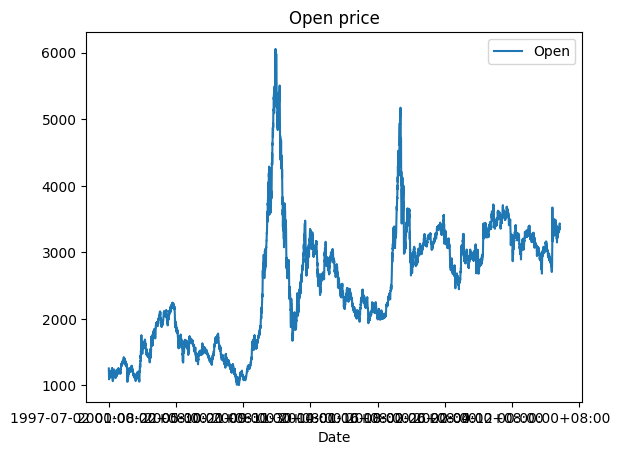

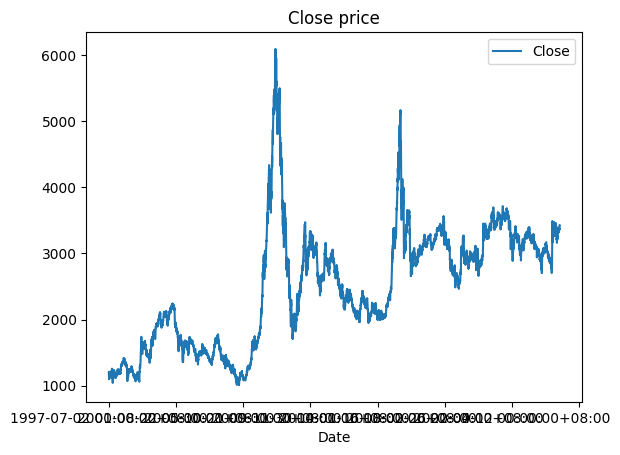

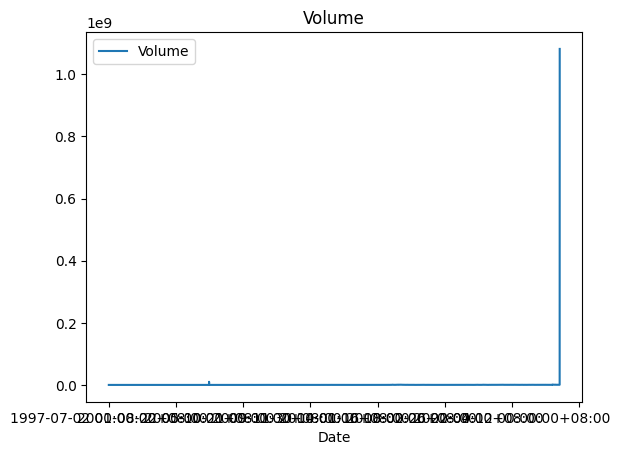

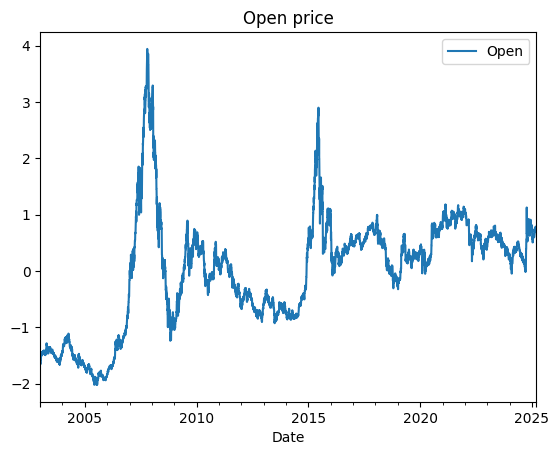

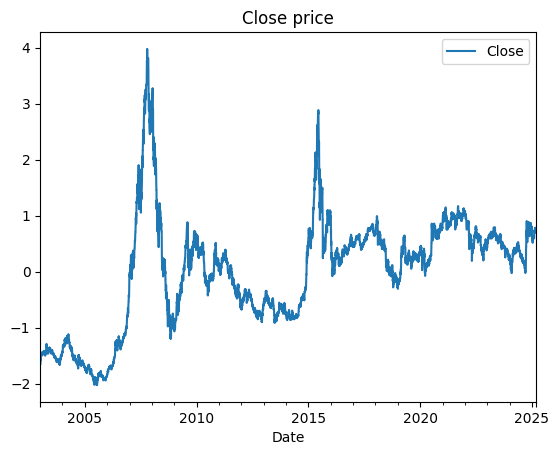

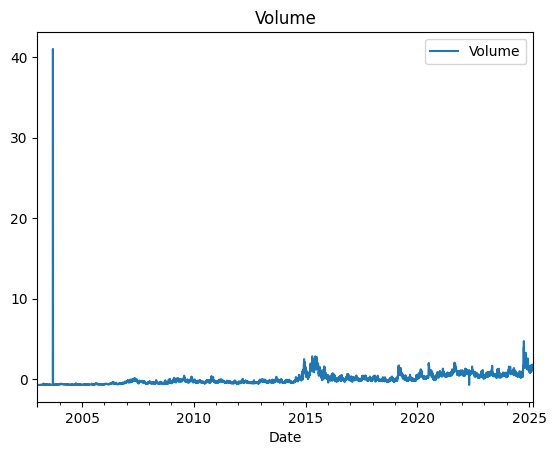

In [123]:
plot_df_asset(load_df_from_csv(data_directory, assets[0]))
plot_df_asset(concatenated_df[concatenated_df["Ticker"] == assets[0]])

As data is correctly standardized, we will remove the original columns and save the new dataframe to a new csv file. Also, instead to store the same value for mean and std for each row, we will store the mean and std for each asset.

In [124]:
mean_std_columns = concatenated_df.columns[concatenated_df.columns.str.contains('_mean') | concatenated_df.columns.str.contains('_std')]
mean_std_columns

Index(['Open_mean', 'Open_std', 'High_mean', 'High_std', 'Low_mean', 'Low_std',
       'Close_mean', 'Close_std', 'Volume_mean', 'Volume_std'],
      dtype='object')

In [125]:
mean_std_list_dict = []

We are now creating our mean/std dataframe, we will use it to inverse the standardization later.

In [17]:
for asset in tqdm(concatenated_df["Ticker"].unique()):
    asset_df = concatenated_df[concatenated_df["Ticker"] == asset]
    asset_mean_std_dict = {"Ticker": asset}
    for column in mean_std_columns:
        asset_mean_std_dict[column] = asset_df[column].iloc[0]
    mean_std_list_dict.append(asset_mean_std_dict)

100%|██████████| 643/643 [01:58<00:00,  5.41it/s]


In [18]:
mean_std_list_df = pd.DataFrame(mean_std_list_dict)
mean_std_list_df

,Ticker,Open_mean,Open_std,High_mean,High_std,Low_mean,Low_std,Close_mean,Close_std,Volume_mean,Volume_std
0,000001.SS,2720.952665,846.297141,2744.256785,855.001950,2698.080982,835.698185,2724.086145,846.868132,1.764160e+05,2.410078e+05
1,0001.HK,43.500155,15.979528,43.904025,16.066757,43.066426,15.873576,43.486960,15.959315,6.825908e+06,4.225270e+06
2,0002.HK,41.602704,16.977079,41.864692,17.080063,41.301743,16.864127,41.593455,16.981717,3.209230e+06,2.013155e+06
3,0011.HK,80.262320,32.917319,80.880009,33.181514,79.536954,32.605017,80.233542,32.918423,1.939968e+06,1.451897e+06
4,0019.HK,43.668868,13.309214,44.123642,13.415283,43.180365,13.180119,43.656727,13.285411,2.068948e+06,1.490160e+06
...,...,...,...,...,...,...,...,...,...,...,...
638,XOM,52.906418,23.051966,53.389110,23.263616,52.417949,22.841870,52.914536,23.048264,1.893203e+07,1.061677e+07
639,YUM,53.818562,40.815954,54.283980,41.121623,53.354176,40.505135,53.832118,40.814962,3.767305e+06,2.760226e+06
640,ZBH,85.466379,31.771407,86.319182,32.030967,84.598984,31.466763,85.481966,31.744263,1.602386e+06,1.001153e+06
641,ZBRA,129.940497,136.529530,131.588353,138.179120,128.148559,134.584790,129.938581,136.449423,4.354248e+05,4.366121e+05


Checking that we have the same number of assets in the mean_std_list_df as in the concatenated_df 

In [19]:
assert len(mean_std_list_df) == len(concatenated_df["Ticker"].unique()), 'Different number of assets'

Saving the mean and std values to CSV

In [314]:
mean_std_list_df.to_csv(os.path.join(data_directory, '../assets_default_mean_std_data.csv'), index=False)

We can now remove the mean and std columns from the concatenated_df, we also remove columns that are not needed for the model (e.g. dividends, stock splits)

In [126]:
columns_to_drop = list(mean_std_columns) + ['Dividends', 'Stock Splits']
columns_to_drop

['Open_mean',
 'Open_std',
 'High_mean',
 'High_std',
 'Low_mean',
 'Low_std',
 'Close_mean',
 'Close_std',
 'Volume_mean',
 'Volume_std',
 'Dividends',
 'Stock Splits']

In [ ]:
concatenated_df_no_useless = concatenated_df.drop(columns=columns_to_drop)

Finally, we save the concatenated dataframe without useless columns to a CSV file.

In [22]:
concatenated_df_no_useless.to_csv(os.path.join(data_directory, '../cleaned_assets_price_volume_data.csv'), index=False)